In [2]:
from pathlib import Path
from datasets import load_dataset
import ipynbname

notebook_path = Path(ipynbname.path())
PROJECT_ROOT = notebook_path.parent.parent

data_path = PROJECT_ROOT / "data" / "winoground_local" / "data" / "examples.jsonl"

examples = load_dataset("json", data_files=str(data_path))

/home/karim/Desktop/multi-modals/clip-interpretability-via-sae/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import pandas as pd

df = examples["train"].to_pandas()
df.head()

,id,caption_0,caption_1,image_0,image_1,tag,secondary_tag,num_main_preds,collapsed_tag
0,0,an old person kisses a young person,a young person kisses an old person,ex_0_img_0,ex_0_img_1,Adjective-Age,,1,Relation
1,1,the taller person hugs the shorter person,the shorter person hugs the taller person,ex_1_img_0,ex_1_img_1,Adjective-Size,,1,Relation
2,2,the masked wrestler hits the unmasked wrestler,the unmasked wrestler hits the masked wrestler,ex_2_img_0,ex_2_img_1,Adjective-Manner,Series,1,Relation
3,3,a person watches an animal,an animal watches a person,ex_3_img_0,ex_3_img_1,Noun,,1,Object
4,4,the person without earrings pays the person wi...,the person with earrings pays the person witho...,ex_4_img_0,ex_4_img_1,"Negation, Scope",Morpheme-Level,1,Relation


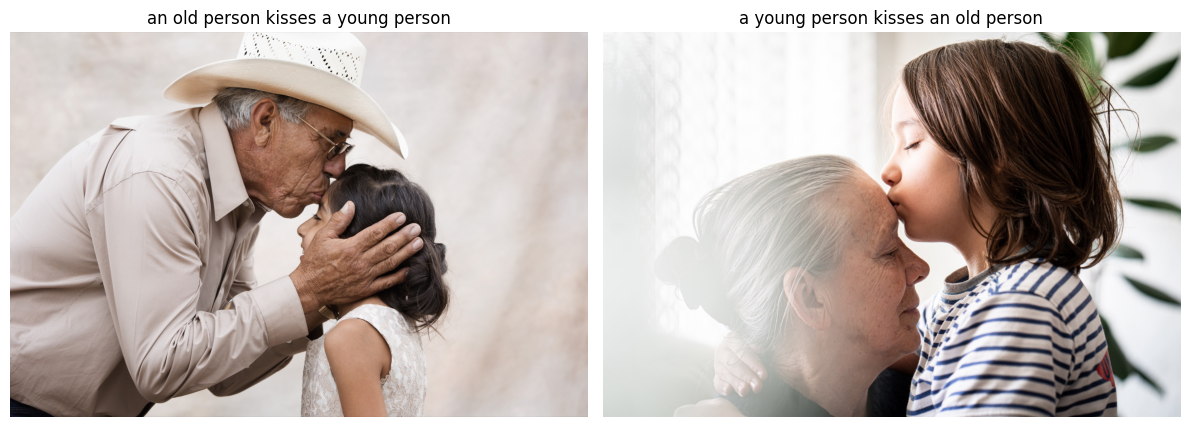

In [4]:
from PIL import Image
from matplotlib import pyplot as plt

def get_image_pair(example_row):
    img_path = PROJECT_ROOT / "data" / "winoground_local" / "data" / "images"
    image_1 = Image.open(f"{img_path}/ex_{example_row}_img_0.png")
    image_2 = Image.open(f"{img_path}/ex_{example_row}_img_1.png")
    return image_1, image_2

row = df.iloc[0]
image_1, image_2 = get_image_pair(0)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_1)
plt.title(f"{row.caption_0}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image_2)
plt.title(f"{row.caption_1}")
plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
from PIL import Image
import requests

from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("wkcn/TinyCLIP-ViT-8M-16-Text-3M-YFCC15M")
processor = CLIPProcessor.from_pretrained("wkcn/TinyCLIP-ViT-8M-16-Text-3M-YFCC15M")

row = df.iloc[0]
image_1, image_2 = get_image_pair(0)
img_list = [image_1, image_2]
for i in range(len(img_list)):
    inputs = processor(
        text=[f"{row.caption_0}", f"{row.caption_1}"],
        images=img_list[i], return_tensors="pt", padding=True)
    outputs = model(**inputs)
    logits_per_image = outputs.logits_per_image
    probs = logits_per_image.softmax(dim=1)
    print(f"Probability of {row.caption_0} being correct: {probs[0][0].item()}")
    print(f"Probability of {row.caption_1} being correct: {probs[0][1].item()}")

print(probs)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Probability of an old person kisses a young person being correct: 0.5437704920768738
Probability of a young person kisses an old person being correct: 0.45622947812080383
Probability of an old person kisses a young person being correct: 0.5677105188369751
Probability of a young person kisses an old person being correct: 0.4322894215583801
tensor([[0.5677, 0.4323]], grad_fn=<SoftmaxBackward0>)


In [11]:
def evaluate_examples(df: pd.DataFrame):
    import torch
    from tqdm import tqdm
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")
    model.to(device)
    model.eval()
    
    results = []
    pbar = tqdm(df.iterrows(), total=len(df), desc="Evaluating examples")
    for index, row in pbar:
        image_0, image_1 = get_image_pair(index)
        img_list = [image_0.convert("RGB"), image_1.convert("RGB")]
        texts = [row['caption_0'], row['caption_1']]
        
        probs_list = []
        for i in range(len(img_list)):
            inputs = processor(text=texts, images=img_list[i], return_tensors="pt", padding=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
            logits_per_image = outputs.logits_per_image
            probs = logits_per_image.softmax(dim=1)
            probs_list.append(probs[0])
        
        # probs_list[0]: [c0_i0, c1_i0] - Image 0 with Text 0 and Text 1
        # probs_list[1]: [c0_i1, c1_i1] - Image 1 with Text 0 and Text 1
        c0_i0, c1_i0 = probs_list[0][0].item(), probs_list[0][1].item()
        c0_i1, c1_i1 = probs_list[1][0].item(), probs_list[1][1].item()
        
        score = int(c0_i0 > c1_i0) + int(c1_i1 > c0_i1)
        
        results.append({
            'id': row['id'],
            'c0_i0': c0_i0, 'c1_i0': c1_i0, 'c0_i1': c0_i1, 'c1_i1': c1_i1,
            'score': score
        })
        
        pbar.set_postfix({"example": index, "score": score})
    
    return pd.merge(df, pd.DataFrame(results), on='id', how='left')

results = evaluate_examples(df)
results.head()

Using device: cuda


Evaluating examples: 100%|██████████| 400/400 [00:28<00:00, 13.79it/s, example=399, score=1]


,id,caption_0,caption_1,image_0,image_1,tag,secondary_tag,num_main_preds,collapsed_tag,c0_i0,c1_i0,c0_i1,c1_i1,score
0,0,an old person kisses a young person,a young person kisses an old person,ex_0_img_0,ex_0_img_1,Adjective-Age,,1,Relation,0.543770,0.456230,0.567710,0.432290,1
1,1,the taller person hugs the shorter person,the shorter person hugs the taller person,ex_1_img_0,ex_1_img_1,Adjective-Size,,1,Relation,0.559669,0.440331,0.554192,0.445808,1
2,2,the masked wrestler hits the unmasked wrestler,the unmasked wrestler hits the masked wrestler,ex_2_img_0,ex_2_img_1,Adjective-Manner,Series,1,Relation,0.491270,0.508730,0.507904,0.492096,0
3,3,a person watches an animal,an animal watches a person,ex_3_img_0,ex_3_img_1,Noun,,1,Object,0.517168,0.482832,0.609914,0.390086,1
4,4,the person without earrings pays the person wi...,the person with earrings pays the person witho...,ex_4_img_0,ex_4_img_1,"Negation, Scope",Morpheme-Level,1,Relation,0.410766,0.589234,0.449264,0.550736,1


In [13]:
# statistical summary of the results
accuracy = results['score'].mean() / 2  # divide because there are 2 captions for each example
print(f"Accuracy: {accuracy}")


Accuracy: 0.53625


In [17]:
# Testing the mode agains imagenet for object recognition
from datasets import load_dataset
import dotenv
import os
import pandas as pd
from tqdm import tqdm

dotenv.load_dotenv()

# Stream the dataset without downloading it entirely
dataset = load_dataset(
    "ILSVRC/imagenet-1k",
    split="train",
    streaming=True,
    token=os.getenv("HF_TOKEN")
)

# Get the label mapping from the dataset features
label_to_name = dataset.features["label"].int2str

# Collect samples in a list (first 400 samples)
total_samples = 400
samples = []
for sample in tqdm(dataset, total=total_samples, desc="Loading samples"):
    samples.append(sample)
    total_samples -= 1
    if total_samples <= 0:
        break

# Create DataFrame from collected samples
img_net_dataset = pd.DataFrame(samples)

# Add label names column
img_net_dataset["label_name"] = img_net_dataset["label"].map(label_to_name)

Loading samples: 100%|█████████▉| 399/400 [01:24<00:00,  4.72it/s]


In [21]:
img_net_dataset.head()

,image,label,label_name
0,<PIL.JpegImagePlugin.JpegImageFile image mode=...,726,"plane, carpenter's plane, woodworking plane"
1,<PIL.JpegImagePlugin.JpegImageFile image mode=...,917,comic book
2,<PIL.JpegImagePlugin.JpegImageFile image mode=...,13,"junco, snowbird"
3,<PIL.JpegImagePlugin.JpegImageFile image mode=...,939,"zucchini, courgette"
4,<PIL.JpegImagePlugin.JpegImageFile image mode=...,6,stingray


In [22]:
# Add captions column by splitting label_name and creating captions
def create_captions(label_name: str) -> list[str]:
    """Create a list of captions from comma-separated label names."""
    import re
    
    # Split by comma and strip whitespace
    phrases = [phrase.strip() for phrase in label_name.split(",")]
    
    # Create captions with proper article (a/an)
    captions = []
    for phrase in phrases:
        # Determine article based on first letter
        article = "an" if phrase and phrase[0].lower() in "aeiou" else "a"
        caption = f"An image of {article} {phrase}"
        captions.append(caption)
    
    return captions

# Apply the function to create captions
img_net_dataset["captions"] = img_net_dataset["label_name"].apply(create_captions)

img_net_dataset.head()

,image,label,label_name,captions
0,<PIL.JpegImagePlugin.JpegImageFile image mode=...,726,"plane, carpenter's plane, woodworking plane","[An image of a plane, An image of a carpenter'..."
1,<PIL.JpegImagePlugin.JpegImageFile image mode=...,917,comic book,[An image of a comic book]
2,<PIL.JpegImagePlugin.JpegImageFile image mode=...,13,"junco, snowbird","[An image of a junco, An image of a snowbird]"
3,<PIL.JpegImagePlugin.JpegImageFile image mode=...,939,"zucchini, courgette","[An image of a zucchini, An image of a courgette]"
4,<PIL.JpegImagePlugin.JpegImageFile image mode=...,6,stingray,[An image of a stingray]


In [23]:
def evaluate_multiway_accuracy(
    df: pd.DataFrame,
    label_captions: list[str]
) -> dict[str, float]:
    """
    Multi-way retrieval accuracy:
    - label_captions must be ordered so that index i matches df['label'] == i
    """
    import torch
    from tqdm import tqdm

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")
    model.to(device)
    model.eval()

    # Precompute normalized text embeddings
    with torch.no_grad():
        text_inputs = processor(text=label_captions, return_tensors="pt", padding=True).to(device)
        text_embeds = model.get_text_features(**text_inputs)
        text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)

    correct = 0
    total = len(df)

    pbar = tqdm(df.iterrows(), total=total, desc="Evaluating (multi-way)")
    for _, row in pbar:
        image = row["image"].convert("RGB")
        with torch.no_grad():
            image_inputs = processor(images=image, return_tensors="pt").to(device)
            image_embeds = model.get_image_features(**image_inputs)
            image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
            logits = image_embeds @ text_embeds.T  # [1, num_labels]
            pred_idx = int(torch.argmax(logits))

        if pred_idx == int(row["label"]):
            correct += 1
        pbar.set_postfix({"acc": correct / (pbar.n or 1)})

    accuracy = correct / total if total else 0.0
    return {"accuracy": accuracy, "correct": correct, "total": total}

label_to_name = dataset.features["label"].int2str
label_captions = [f"An image of a {label_to_name(i)}" for i in range(dataset.features["label"].num_classes)]
metrics = evaluate_multiway_accuracy(img_net_dataset, label_captions)
print(metrics)


Using device: cuda


Evaluating (multi-way): 100%|██████████| 400/400 [00:03<00:00, 111.57it/s, acc=0.416]

{'accuracy': 0.4075, 'correct': 163, 'total': 400}


In [27]:
import numpy as np

def normalized_accuracy(acc: float, chance: float) -> float:
    """Scale accuracy relative to chance: (acc - chance) / (1 - chance)."""
    if chance >= 1.0:
        raise ValueError("chance must be < 1.0")
    return (acc - chance) / (1.0 - chance)

img_net_normalized_acc = normalized_accuracy(acc=metrics["accuracy"], chance=1/1000)
wino_normalized_acc = normalized_accuracy(acc=accuracy, chance=1/2)

print(f"Normalized accuracy Imagenet: {img_net_normalized_acc}")
print(f"Normalized accuracy Winoground: {wino_normalized_acc}")

Normalized accuracy Imagenet: 0.4069069069069069
Normalized accuracy Winoground: 0.07250000000000001


Interpretation:

- ImageNet (1,000-way): top-1 accuracy ≈ 40.7% vs chance ≈ 0.1%. Normalized accuracy ≈ 0.406, meaning the model closes ~40% of the gap from chance to perfect on a very hard (1k-class) task—solid zero-shot object recognition.
- Winograd-style compositional set (2-way): top-1 accuracy ≈ 53.6% vs chance 50%. Normalized accuracy ≈ 0.073, meaning it closes only ~0.7% of the gap above chance—essentially near-random on relational/compositional judgments.

Interpretation: CLIP shows strong object-recognition ability (far above chance in 1k-way classification) but weak compositional understanding (barely above chance when choosing between two relational captions). This aligns with the compositionality.